In [13]:
%matplotlib inline

In [25]:
import logging

# qcodes imports
from qcodes.dataset import (
    Measurement,
    load_experiment_by_name,
    new_experiment,
    plot_by_id,
)
from qcodes.instrument_drivers.Keysight import KeysightN5245A

# setup
logger = logging.getLogger()
logger.setLevel(logging.DEBUG)

# Start experiment
exp_name = "Cavity"
sample_name = "Thru_Coax"

try:
    exp = load_experiment_by_name(exp_name, sample = sample_name)
    print("Experiment loaded. Last ID no:", exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print("Starting new experiment.")

Experiment loaded. Last ID no: 3


In [50]:
pnd = KeysightN5245A("pnd", "USB0::0x2A8D::0x0001::MY55100528::INSTR")

Connected to: Keysight Technologies E5080A (serial:MY55100528, firmware:A.12.60.03) in 0.16s


In [38]:
#Power = -10dB
pnc.power(-30)
#have a frequency range from 1Ghz to 1.2GHz
pnc.start(100e6)
pnc.stop(1e9)
#Have 1001 points to average over
pnc.points(1001)
#Do methods S21
pnc.trace("S21")

pnc.if_bandwidth(1e3)
pnc.averages_enabled(True)
pnc.averages(2)
#
meas = Measurement()
meas.register_parameter(pnc.magnitude)

with meas.run() as datasaver:
    mag = pnc.magnitude()
    datasaver.add_result((pnc.magnitude, mag))
    dataid = datasaver.run_id
plot_by_id(dataid)

Starting experimental run with id: 11. 


An exception occurred in measurement with guid: 7faa440d-0000-0000-0000-019ff7abcfbe;
Traceback:
Traceback (most recent call last):
  File "/var/folders/nt/lfptrtf11fx05y3_34w6b8r00000gq/T/ipykernel_9675/1068011306.py", line 19, in <module>
    mag = pnc.magnitude()
          ^^^^^^^^^^^^^^^
  File "/Users/bordeim1/Desktop/python/myvenv/lib/python3.12/site-packages/qcodes/parameters/parameter_base.py", line 689, in __call__
    return self.get()
           ^^^^^^^^^^
  File "/Users/bordeim1/Desktop/python/myvenv/lib/python3.12/site-packages/qcodes/parameters/parameter_base.py", line 909, in get_wrapper
    raise e
  File "/Users/bordeim1/Desktop/python/myvenv/lib/python3.12/site-packages/qcodes/parameters/parameter_base.py", line 896, in get_wrapper
    raw_value = get_function(*args, **kwargs)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/bordeim1/Desktop/python/myvenv/lib/python3.12/site-packages/qcodes/instrument_drivers/Keysight/N52xx.py", line 137, in get_raw
    da

ValueError: ('Could not find hash sign ("#") indicating the start of the block. The block begins with bytearray(b\'-8.19972839355E+001,-9.25\')', 'getting pnc_tr1_magnitude')

In [48]:
# Set up a frequency sweep from 100 MHz to 1 GHz, with 1001 points, at a power of -40dBm
pnc.power(-30)
pnc.start(100e6)
pnc.stop(1e9)
pnc.points(1001)
pnc.trace("S21")

# Enable 2 averages, and set IF BW to 1kHz
pnc.if_bandwidth(1e3)
pnc.averages_enabled(True)
pnc.averages(2)

pnc.format("REAL,64")  
pnc.traces.tr1.format("MLOG") 
# Run a measurement
meas = Measurement()
meas.register_parameter(pnc.magnitude)


with meas.run() as datasaver:
    mag = pnc.magnitude()
    datasaver.add_result((pnc.magnitude, mag))
    dataid = datasaver.run_id
plot_by_id(dataid)

ValueError: ("'REAL,64' is not in {'REAL', 'POLAR', 'MLOG', 'MLIN', 'IMAG', 'UPH', 'PHAS'}; Parameter: pnc_tr1.format", 'setting pnc_tr1_format to REAL,64')

In [62]:
import matplotlib.pyplot as plt
from qcodes.dataset import plot_dataset

Starting experimental run with id: 26. 


([<Axes: title={'center': 'Run #26, Experiment Cavity (Thru_Coax)'}, xlabel='Frequency (GHz)', ylabel='Magnitude (dB)'>],
 [None])

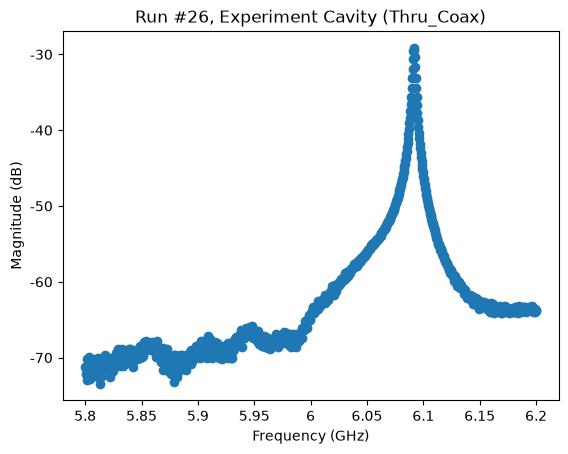

In [60]:
# Set up a frequency sweep from 100 MHz to 1 GHz, with 1001 points, at a power of -40dBm
pnd.power(-30)
pnd.start(5.8e9)
pnd.stop(6.2e9)
pnd.points(1001)
pnd.trace("S21")

# Enable 2 averages, and set IF BW to 1kHz
pnd.if_bandwidth(1e3)
pnd.averages_enabled(True)
pnd.averages(10)

# Run a measurement
meas = Measurement()
meas.register_parameter(pnd.magnitude)

with meas.run() as datasaver:
    mag = pnd.magnitude()
    datasaver.add_result((pnd.magnitude, mag))
    dataid = datasaver.run_id
plot_by_id(dataid)

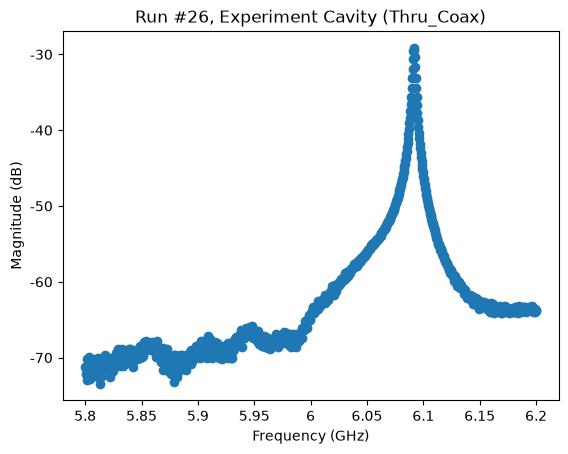

In [64]:
axes, colorbars = plot_by_id(dataid)
fig = axes[0].figure
fig.savefig(f"qcodes_cavity_expirement.png")